1. FULL 50-CLASS CONFUSION MATRIX & METRICS

Classification Report (50 classes):

              precision    recall  f1-score   support

           0       0.56      0.62      0.59         8
           1       0.41      0.88      0.56         8
           2       0.40      0.50      0.44         8
           3       0.55      0.75      0.63         8
           4       0.30      0.88      0.45         8
           5       0.20      0.12      0.15         8
           6       0.00      0.00      0.00         8
           7       0.00      0.00      0.00         8
           8       0.00      0.00      0.00         8
           9       0.14      0.12      0.13         8
          10       1.00      0.88      0.93         8
          11       0.60      0.75      0.67         8
          12       0.62      1.00      0.76         8
          13       0.29      0.25      0.27         8
          14       0.36      0.50      0.42         8
          15       0.60      0.38      0.46         8

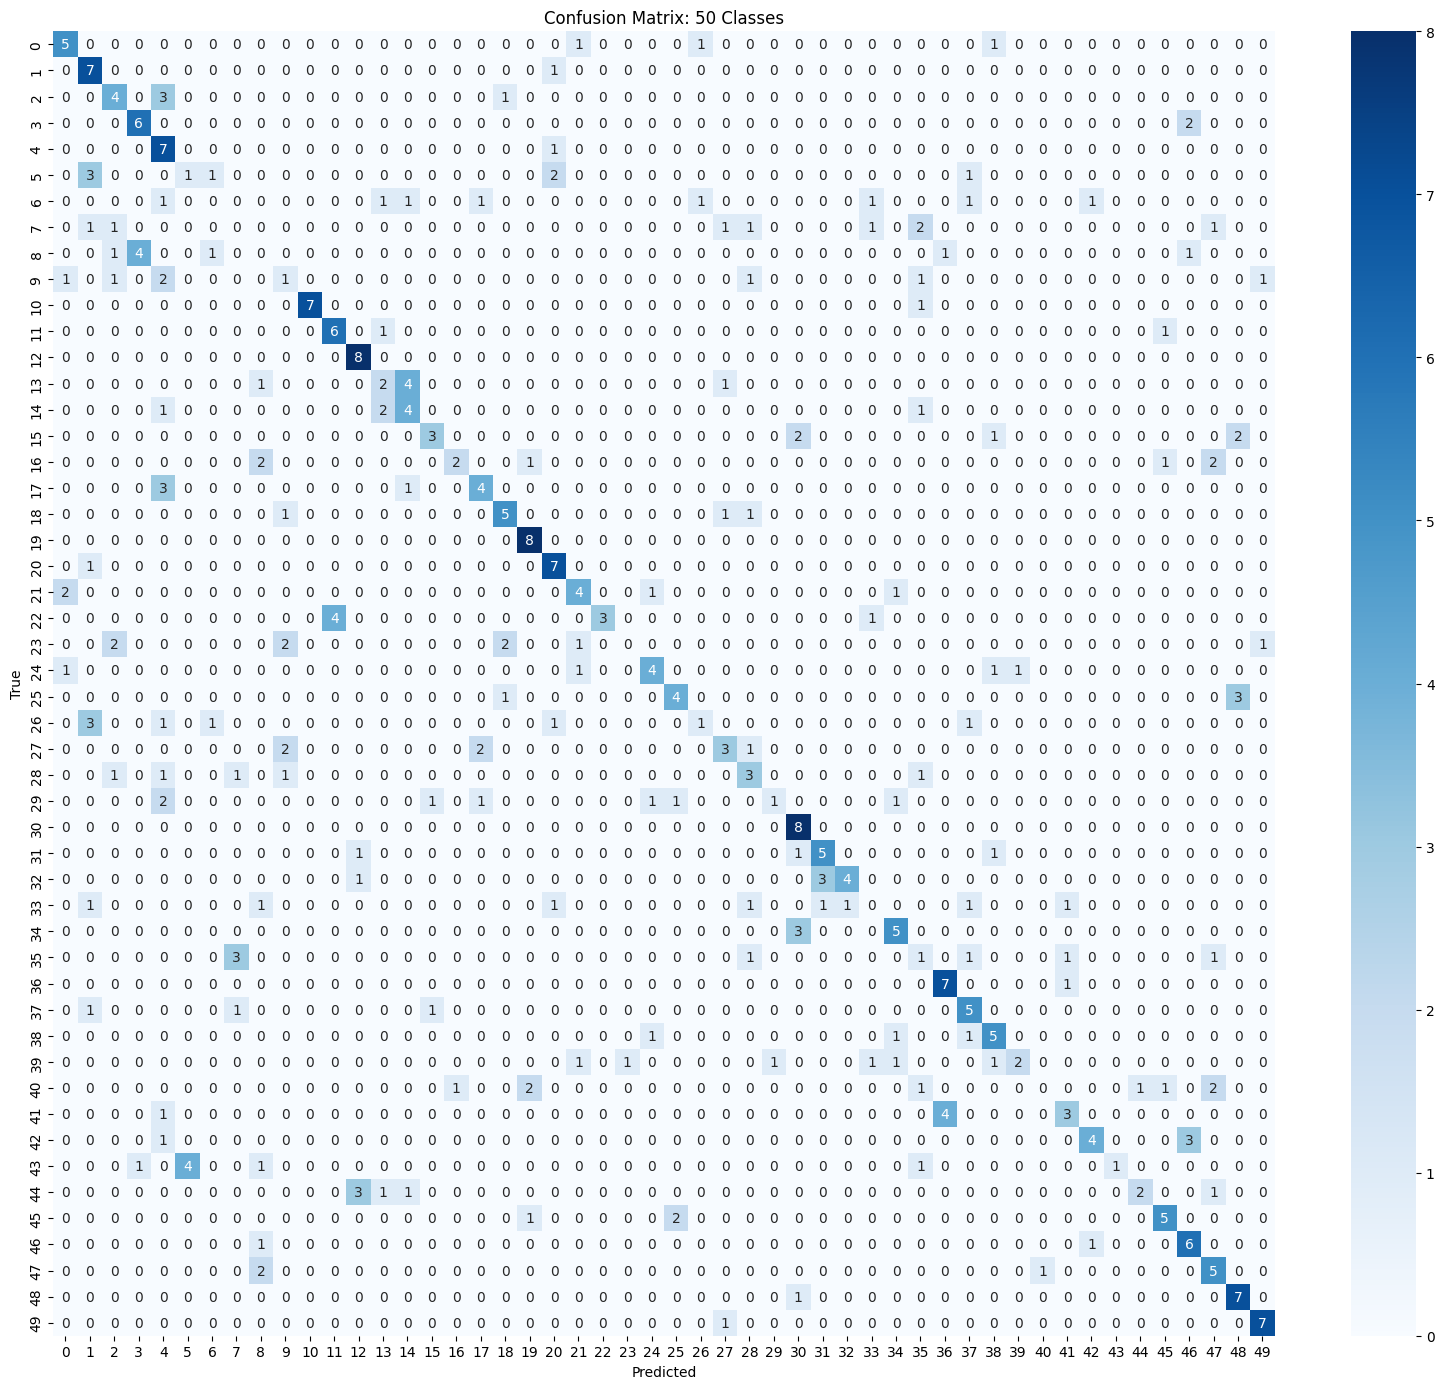


2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS

Classification Report (5 categories):

              precision    recall  f1-score   support

     Animals       0.52      0.64      0.57        80
     Natural       0.68      0.72      0.70        80
       Human       0.62      0.46      0.53        80
    Domestic       0.68      0.74      0.71        80
       Urban       0.71      0.62      0.67        80

    accuracy                           0.64       400
   macro avg       0.64      0.64      0.64       400
weighted avg       0.64      0.64      0.64       400



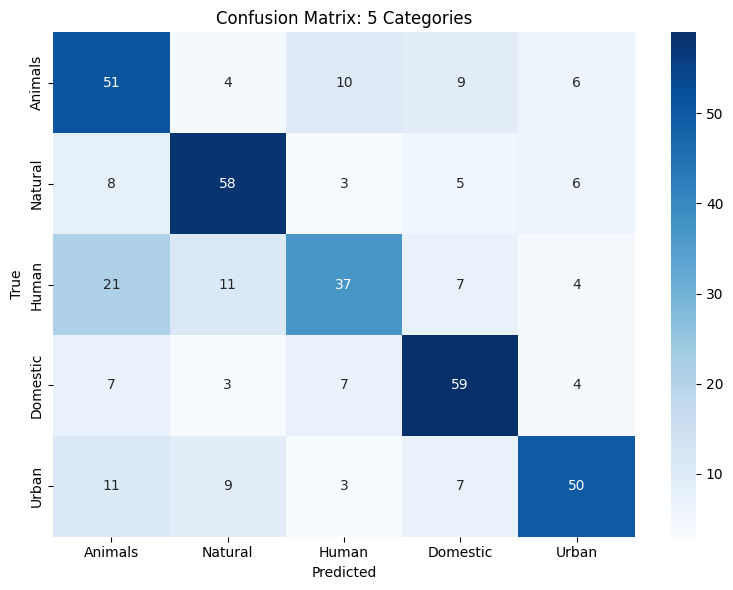

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn tới file predictions.csv của bạn
predictions_csv = "../../../checkpoints/cnn_melspectrogram/predictions.csv"

# ------------------------------------------------------------
# Hàm ánh xạ nhãn -> category
# ------------------------------------------------------------
def get_category(label):
    if 0 <= label <= 9:
        return 0   # Animals
    elif 10 <= label <= 19:
        return 1   # Natural soundscapes & water
    elif 20 <= label <= 29:
        return 2   # Human non-speech
    elif 30 <= label <= 39:
        return 3   # Interior/domestic
    elif 40 <= label <= 49:
        return 4   # Exterior/urban
    else:
        raise ValueError(f"Label {label} out of range 0-49")

def plot_confusion_matrix(cm, labels, title, figsize=(12,10), fmt='d'):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Đọc dữ liệu
# ------------------------------------------------------------
df = pd.read_csv(predictions_csv)
y_true = df['target'].values
y_pred = df['predicted'].values

# ------------------------------------------------------------
# 1. Ma trận nhầm lẫn 50 lớp và classification report
# ------------------------------------------------------------
print("=" * 80)
print("1. FULL 50-CLASS CONFUSION MATRIX & METRICS")
print("=" * 80)

labels_50 = list(range(50))
cm_50 = confusion_matrix(y_true, y_pred, labels=labels_50)

# In báo cáo phân loại chi tiết (precision, recall, f1-score cho từng lớp)
print("\nClassification Report (50 classes):\n")
print(classification_report(y_true, y_pred, labels=labels_50, zero_division=0))

# Vẽ ma trận nhầm lẫn 50x50 (có thể phóng to nếu cần)
plot_confusion_matrix(cm_50, labels_50, title="Confusion Matrix: 50 Classes", figsize=(16,14))

# ------------------------------------------------------------
# 2. Gộp thành 5 categories
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS")
print("=" * 80)

y_true_cat = np.array([get_category(l) for l in y_true])
y_pred_cat = np.array([get_category(l) for l in y_pred])

cat_labels = ["Animals", "Natural", "Human", "Domestic", "Urban"]
cm_cat = confusion_matrix(y_true_cat, y_pred_cat, labels=range(5))

# In báo cáo phân loại cho 5 category
print("\nClassification Report (5 categories):\n")
print(classification_report(y_true_cat, y_pred_cat, labels=range(5),
                            target_names=cat_labels, zero_division=0))

# Vẽ ma trận nhầm lẫn 5x5
plot_confusion_matrix(cm_cat, cat_labels, title="Confusion Matrix: 5 Categories", figsize=(8,6))

1. FULL 50-CLASS CONFUSION MATRIX & METRICS

Classification Report (50 classes):

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         8
           1       0.57      1.00      0.73         8
           2       0.23      0.38      0.29         8
           3       0.36      0.50      0.42         8
           4       0.50      0.50      0.50         8
           5       0.60      0.38      0.46         8
           6       0.67      0.25      0.36         8
           7       0.29      0.50      0.36         8
           8       0.29      0.25      0.27         8
           9       0.64      0.88      0.74         8
          10       0.86      0.75      0.80         8
          11       0.40      0.75      0.52         8
          12       0.86      0.75      0.80         8
          13       0.43      0.38      0.40         8
          14       0.50      0.50      0.50         8
          15       0.33      0.12      0.18         8

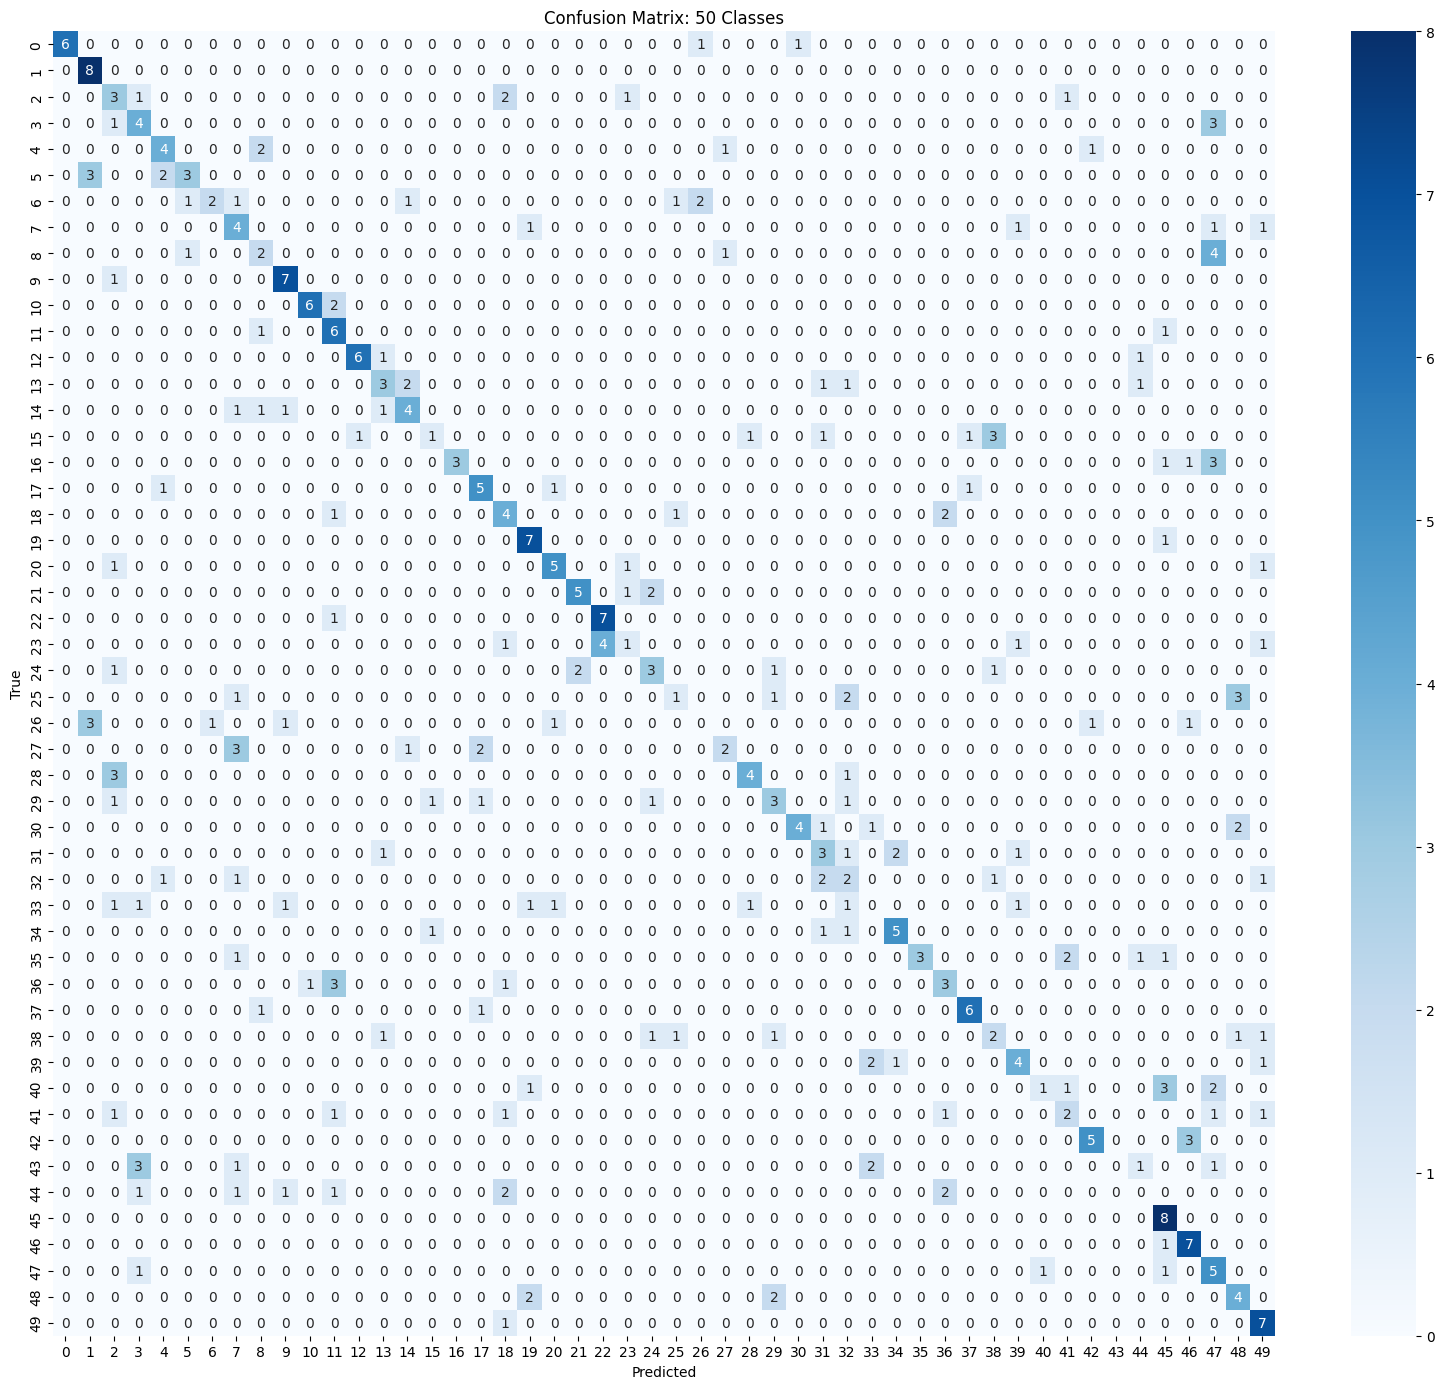


2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS

Classification Report (5 categories):

              precision    recall  f1-score   support

     Animals       0.61      0.70      0.65        80
     Natural       0.64      0.66      0.65        80
       Human       0.73      0.56      0.63        80
    Domestic       0.68      0.60      0.64        80
       Urban       0.60      0.69      0.64        80

    accuracy                           0.64       400
   macro avg       0.65      0.64      0.64       400
weighted avg       0.65      0.64      0.64       400



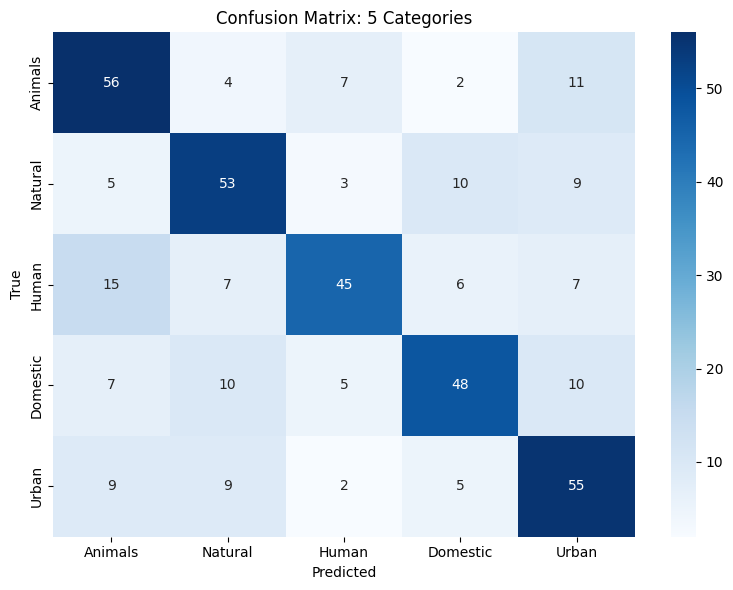

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn tới file predictions.csv của bạn
predictions_csv = "../../../checkpoints/cnn_mfcc/predictions.csv"

# ------------------------------------------------------------
# Hàm ánh xạ nhãn -> category
# ------------------------------------------------------------
def get_category(label):
    if 0 <= label <= 9:
        return 0   # Animals
    elif 10 <= label <= 19:
        return 1   # Natural soundscapes & water
    elif 20 <= label <= 29:
        return 2   # Human non-speech
    elif 30 <= label <= 39:
        return 3   # Interior/domestic
    elif 40 <= label <= 49:
        return 4   # Exterior/urban
    else:
        raise ValueError(f"Label {label} out of range 0-49")

def plot_confusion_matrix(cm, labels, title, figsize=(12,10), fmt='d'):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Đọc dữ liệu
# ------------------------------------------------------------
df = pd.read_csv(predictions_csv)
y_true = df['target'].values
y_pred = df['predicted'].values

# ------------------------------------------------------------
# 1. Ma trận nhầm lẫn 50 lớp và classification report
# ------------------------------------------------------------
print("=" * 80)
print("1. FULL 50-CLASS CONFUSION MATRIX & METRICS")
print("=" * 80)

labels_50 = list(range(50))
cm_50 = confusion_matrix(y_true, y_pred, labels=labels_50)

# In báo cáo phân loại chi tiết (precision, recall, f1-score cho từng lớp)
print("\nClassification Report (50 classes):\n")
print(classification_report(y_true, y_pred, labels=labels_50, zero_division=0))

# Vẽ ma trận nhầm lẫn 50x50 (có thể phóng to nếu cần)
plot_confusion_matrix(cm_50, labels_50, title="Confusion Matrix: 50 Classes", figsize=(16,14))

# ------------------------------------------------------------
# 2. Gộp thành 5 categories
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS")
print("=" * 80)

y_true_cat = np.array([get_category(l) for l in y_true])
y_pred_cat = np.array([get_category(l) for l in y_pred])

cat_labels = ["Animals", "Natural", "Human", "Domestic", "Urban"]
cm_cat = confusion_matrix(y_true_cat, y_pred_cat, labels=range(5))

# In báo cáo phân loại cho 5 category
print("\nClassification Report (5 categories):\n")
print(classification_report(y_true_cat, y_pred_cat, labels=range(5),
                            target_names=cat_labels, zero_division=0))

# Vẽ ma trận nhầm lẫn 5x5
plot_confusion_matrix(cm_cat, cat_labels, title="Confusion Matrix: 5 Categories", figsize=(8,6))

##  a

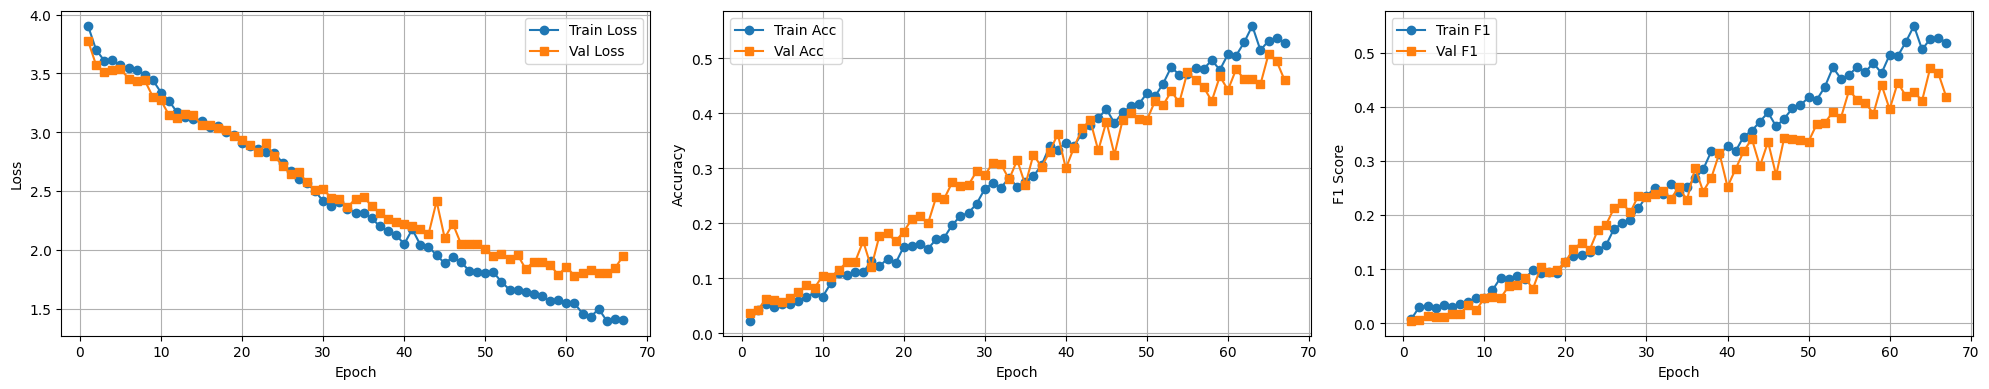

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Đường dẫn đến file CSV của bạn
path = "../../../checkpoints/cnn_melspectrogram/history.csv"   # ← thay bằng path thật

# Đọc dữ liệu
df = pd.read_csv(path)

# Vẽ 3 biểu đồ con
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

# Loss
axes[0].plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o')
axes[0].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(df['epoch'], df['train_acc'], label='Train Acc', marker='o')
axes[1].plot(df['epoch'], df['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# F1
axes[2].plot(df['epoch'], df['train_f1'], label='Train F1', marker='o')
axes[2].plot(df['epoch'], df['val_f1'], label='Val F1', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

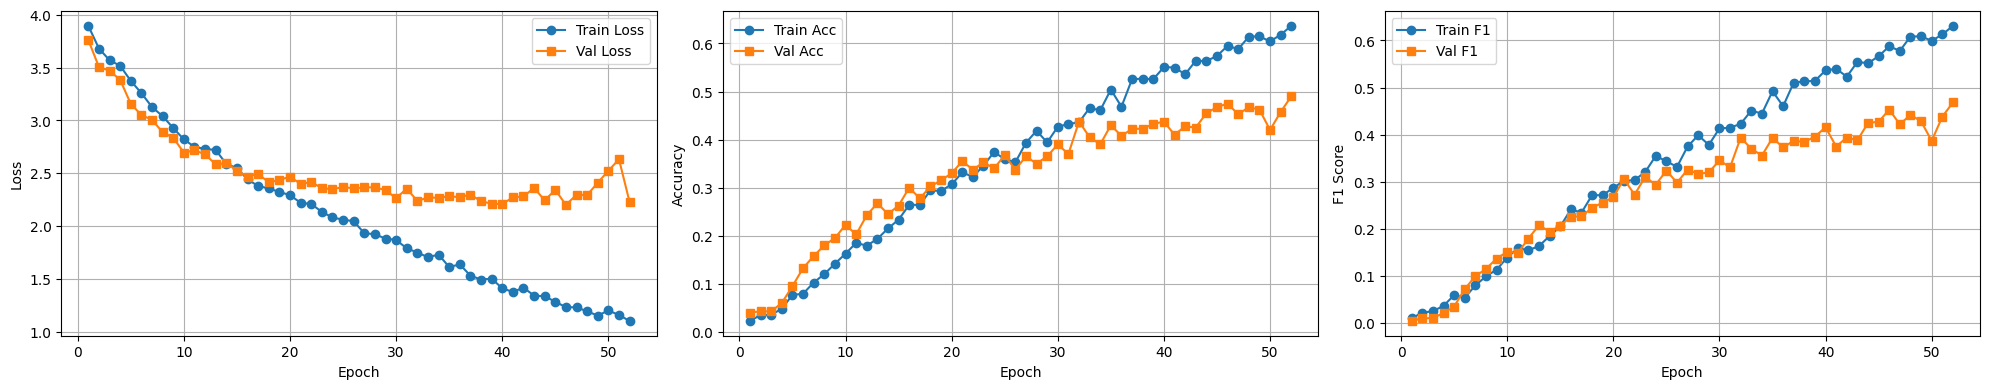

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Đường dẫn đến file CSV của bạn
path = "../../../checkpoints/cnn_mfcc/history.csv"   # ← thay bằng path thật

# Đọc dữ liệu
df = pd.read_csv(path)

# Vẽ 3 biểu đồ con
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

# Loss
axes[0].plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o')
axes[0].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(df['epoch'], df['train_acc'], label='Train Acc', marker='o')
axes[1].plot(df['epoch'], df['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# F1
axes[2].plot(df['epoch'], df['train_f1'], label='Train F1', marker='o')
axes[2].plot(df['epoch'], df['val_f1'], label='Val F1', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Others

1. FULL 50-CLASS CONFUSION MATRIX & METRICS

Classification Report (50 classes):

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00         8
           3       0.06      0.12      0.08         8
           4       0.03      0.12      0.05         8
           5       0.07      0.12      0.09         8
           6       0.00      0.00      0.00         8
           7       0.00      0.00      0.00         8
           8       0.00      0.00      0.00         8
           9       0.19      0.38      0.25         8
          10       0.50      0.12      0.20         8
          11       0.27      0.88      0.41         8
          12       0.00      0.00      0.00         8
          13       0.00      0.00      0.00         8
          14       0.07      0.12      0.09         8
          15       0.00      0.00      0.00         8

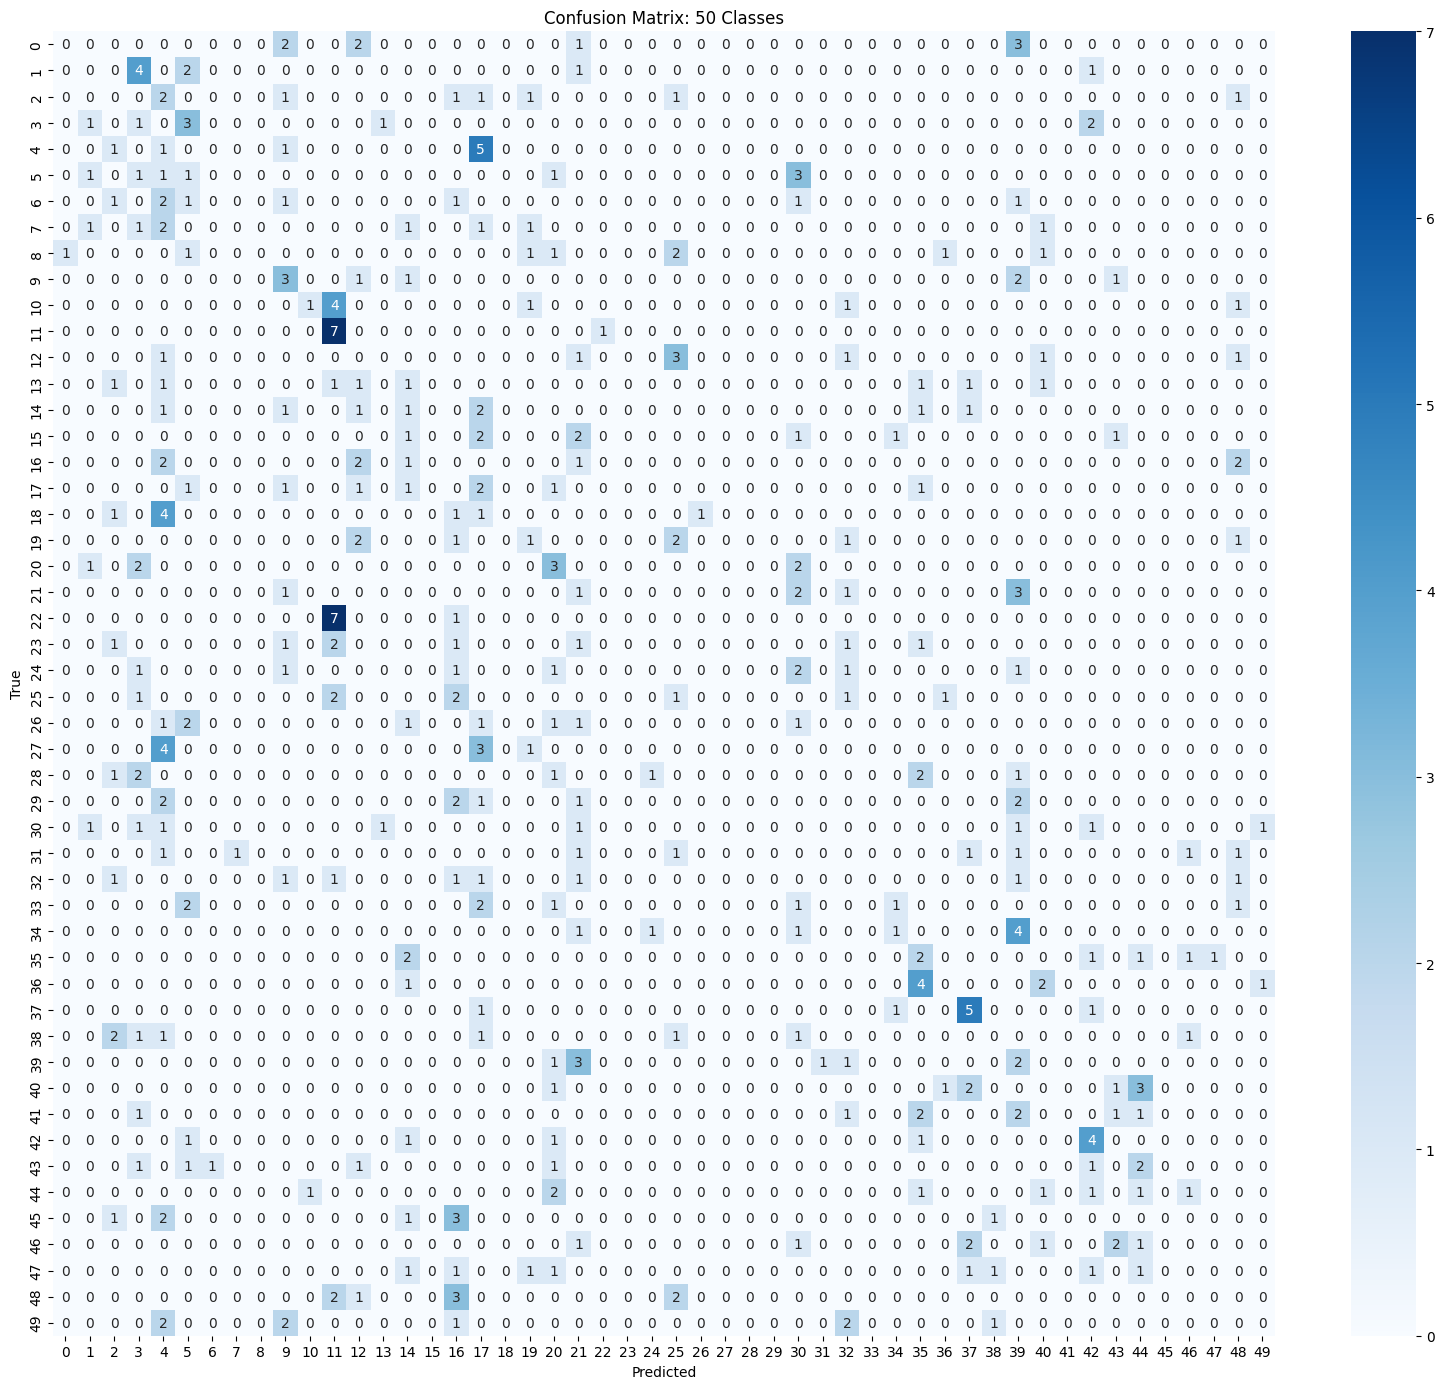


2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS

Classification Report (5 categories):

              precision    recall  f1-score   support

     Animals       0.38      0.46      0.42        80
     Natural       0.34      0.45      0.39        80
       Human       0.23      0.15      0.18        80
    Domestic       0.32      0.36      0.34        80
       Urban       0.43      0.29      0.35        80

    accuracy                           0.34       400
   macro avg       0.34      0.34      0.33       400
weighted avg       0.34      0.34      0.33       400



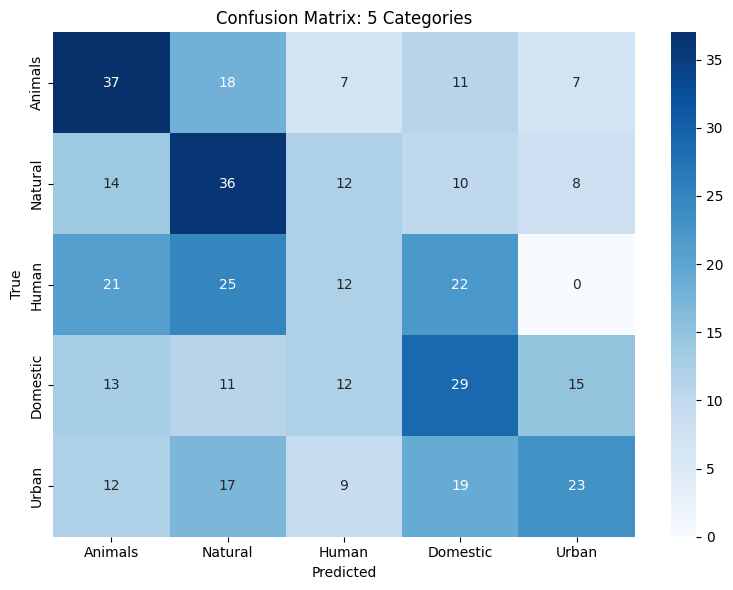

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn tới file predictions.csv của bạn
predictions_csv = "../../../checkpoints/cnn_cens_chromagram/predictions.csv"

# ------------------------------------------------------------
# Hàm ánh xạ nhãn -> category
# ------------------------------------------------------------
def get_category(label):
    if 0 <= label <= 9:
        return 0   # Animals
    elif 10 <= label <= 19:
        return 1   # Natural soundscapes & water
    elif 20 <= label <= 29:
        return 2   # Human non-speech
    elif 30 <= label <= 39:
        return 3   # Interior/domestic
    elif 40 <= label <= 49:
        return 4   # Exterior/urban
    else:
        raise ValueError(f"Label {label} out of range 0-49")

def plot_confusion_matrix(cm, labels, title, figsize=(12,10), fmt='d'):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Đọc dữ liệu
# ------------------------------------------------------------
df = pd.read_csv(predictions_csv)
y_true = df['target'].values
y_pred = df['predicted'].values

# ------------------------------------------------------------
# 1. Ma trận nhầm lẫn 50 lớp và classification report
# ------------------------------------------------------------
print("=" * 80)
print("1. FULL 50-CLASS CONFUSION MATRIX & METRICS")
print("=" * 80)

labels_50 = list(range(50))
cm_50 = confusion_matrix(y_true, y_pred, labels=labels_50)

# In báo cáo phân loại chi tiết (precision, recall, f1-score cho từng lớp)
print("\nClassification Report (50 classes):\n")
print(classification_report(y_true, y_pred, labels=labels_50, zero_division=0))

# Vẽ ma trận nhầm lẫn 50x50 (có thể phóng to nếu cần)
plot_confusion_matrix(cm_50, labels_50, title="Confusion Matrix: 50 Classes", figsize=(16,14))

# ------------------------------------------------------------
# 2. Gộp thành 5 categories
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS")
print("=" * 80)

y_true_cat = np.array([get_category(l) for l in y_true])
y_pred_cat = np.array([get_category(l) for l in y_pred])

cat_labels = ["Animals", "Natural", "Human", "Domestic", "Urban"]
cm_cat = confusion_matrix(y_true_cat, y_pred_cat, labels=range(5))

# In báo cáo phân loại cho 5 category
print("\nClassification Report (5 categories):\n")
print(classification_report(y_true_cat, y_pred_cat, labels=range(5),
                            target_names=cat_labels, zero_division=0))

# Vẽ ma trận nhầm lẫn 5x5
plot_confusion_matrix(cm_cat, cat_labels, title="Confusion Matrix: 5 Categories", figsize=(8,6))

1. FULL 50-CLASS CONFUSION MATRIX & METRICS

Classification Report (50 classes):

              precision    recall  f1-score   support

           0       0.09      0.12      0.11         8
           1       0.47      0.88      0.61         8
           2       0.11      0.12      0.12         8
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00         8
           5       0.07      0.12      0.09         8
           6       0.12      0.12      0.12         8
           7       0.00      0.00      0.00         8
           8       0.36      0.50      0.42         8
           9       0.00      0.00      0.00         8
          10       0.25      0.12      0.17         8
          11       0.24      0.88      0.38         8
          12       0.18      0.25      0.21         8
          13       0.43      0.38      0.40         8
          14       0.00      0.00      0.00         8
          15       0.50      0.38      0.43         8

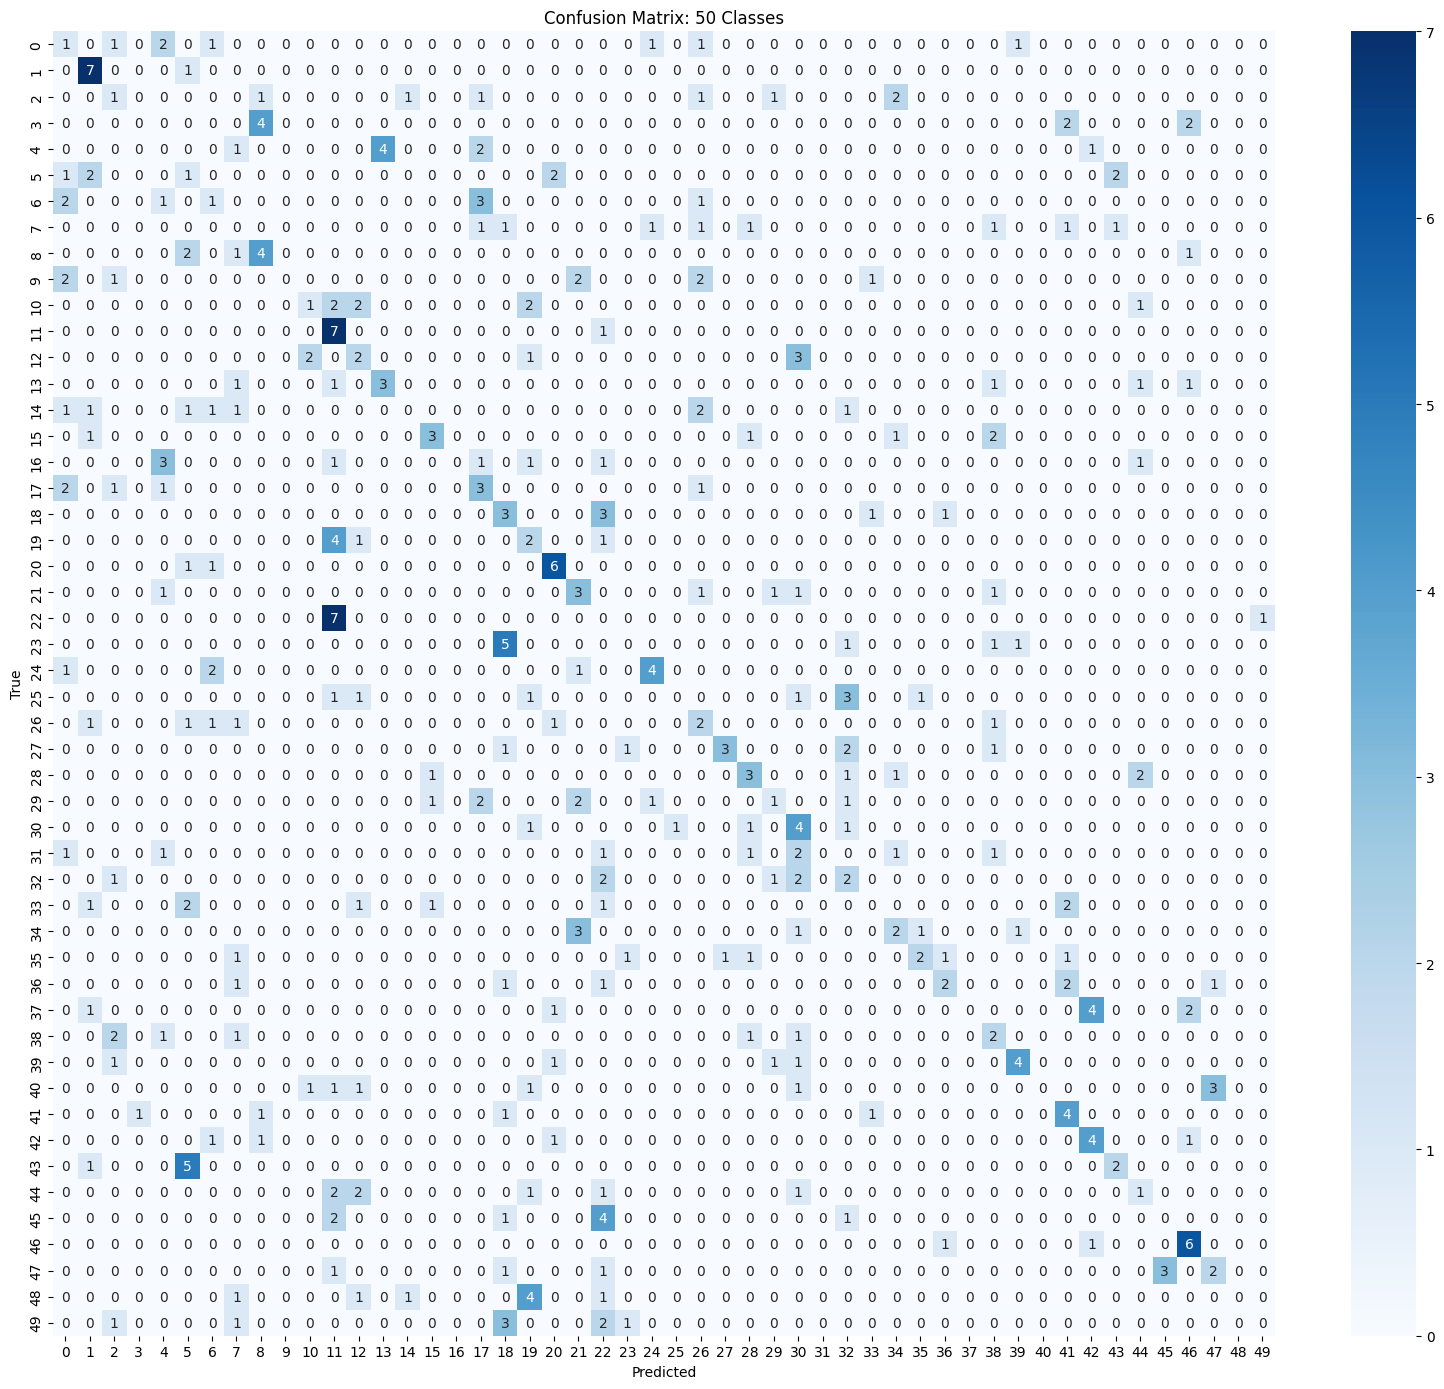


2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS

Classification Report (5 categories):

              precision    recall  f1-score   support

     Animals       0.43      0.47      0.45        80
     Natural       0.41      0.53      0.46        80
       Human       0.36      0.38      0.37        80
    Domestic       0.46      0.39      0.42        80
       Urban       0.48      0.34      0.40        80

    accuracy                           0.42       400
   macro avg       0.43      0.42      0.42       400
weighted avg       0.43      0.42      0.42       400



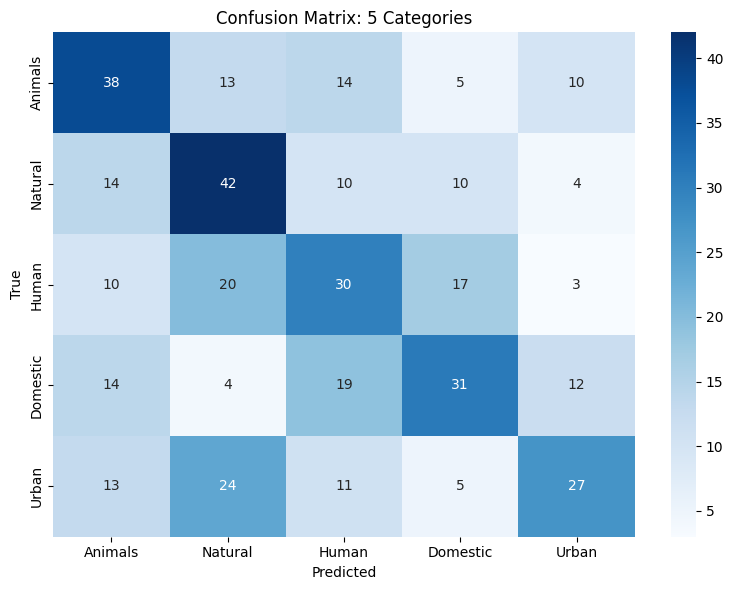

In [13]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn tới file predictions.csv của bạn
predictions_csv = "../../../checkpoints/cnn_chroma_stft/predictions.csv"

# ------------------------------------------------------------
# Hàm ánh xạ nhãn -> category
# ------------------------------------------------------------
def get_category(label):
    if 0 <= label <= 9:
        return 0   # Animals
    elif 10 <= label <= 19:
        return 1   # Natural soundscapes & water
    elif 20 <= label <= 29:
        return 2   # Human non-speech
    elif 30 <= label <= 39:
        return 3   # Interior/domestic
    elif 40 <= label <= 49:
        return 4   # Exterior/urban
    else:
        raise ValueError(f"Label {label} out of range 0-49")

def plot_confusion_matrix(cm, labels, title, figsize=(12,10), fmt='d'):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Đọc dữ liệu
# ------------------------------------------------------------
df = pd.read_csv(predictions_csv)
y_true = df['target'].values
y_pred = df['predicted'].values

# ------------------------------------------------------------
# 1. Ma trận nhầm lẫn 50 lớp và classification report
# ------------------------------------------------------------
print("=" * 80)
print("1. FULL 50-CLASS CONFUSION MATRIX & METRICS")
print("=" * 80)

labels_50 = list(range(50))
cm_50 = confusion_matrix(y_true, y_pred, labels=labels_50)

# In báo cáo phân loại chi tiết (precision, recall, f1-score cho từng lớp)
print("\nClassification Report (50 classes):\n")
print(classification_report(y_true, y_pred, labels=labels_50, zero_division=0))

# Vẽ ma trận nhầm lẫn 50x50 (có thể phóng to nếu cần)
plot_confusion_matrix(cm_50, labels_50, title="Confusion Matrix: 50 Classes", figsize=(16,14))

# ------------------------------------------------------------
# 2. Gộp thành 5 categories
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS")
print("=" * 80)

y_true_cat = np.array([get_category(l) for l in y_true])
y_pred_cat = np.array([get_category(l) for l in y_pred])

cat_labels = ["Animals", "Natural", "Human", "Domestic", "Urban"]
cm_cat = confusion_matrix(y_true_cat, y_pred_cat, labels=range(5))

# In báo cáo phân loại cho 5 category
print("\nClassification Report (5 categories):\n")
print(classification_report(y_true_cat, y_pred_cat, labels=range(5),
                            target_names=cat_labels, zero_division=0))

# Vẽ ma trận nhầm lẫn 5x5
plot_confusion_matrix(cm_cat, cat_labels, title="Confusion Matrix: 5 Categories", figsize=(8,6))

1. FULL 50-CLASS CONFUSION MATRIX & METRICS

Classification Report (50 classes):

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.50      0.62      0.56         8
           2       0.09      0.12      0.11         8
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00         8
           5       0.12      0.25      0.16         8
           6       0.20      0.12      0.15         8
           7       0.25      0.25      0.25         8
           8       0.27      0.38      0.32         8
           9       0.17      0.25      0.20         8
          10       0.25      0.12      0.17         8
          11       0.64      0.88      0.74         8
          12       0.17      0.50      0.26         8
          13       0.33      0.25      0.29         8
          14       1.00      0.38      0.55         8
          15       0.00      0.00      0.00         8

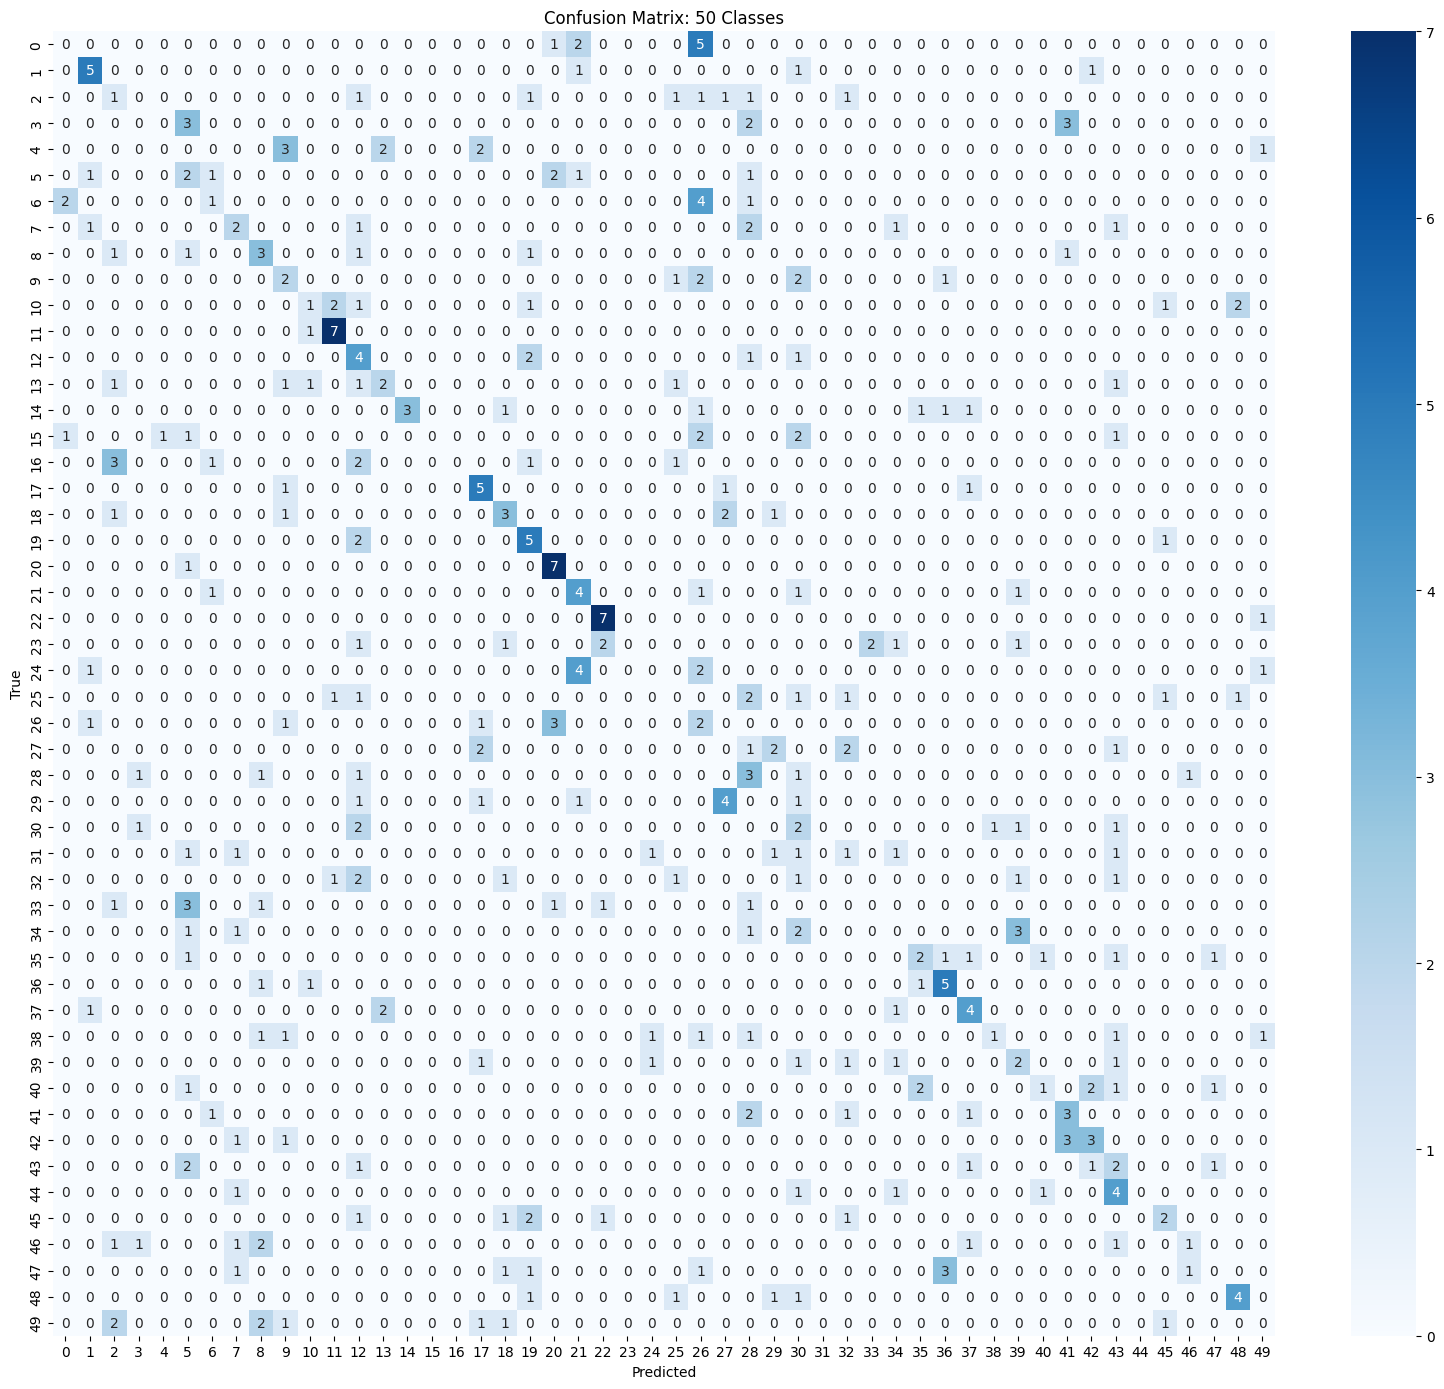


2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS

Classification Report (5 categories):

              precision    recall  f1-score   support

     Animals       0.36      0.36      0.36        80
     Natural       0.54      0.56      0.55        80
       Human       0.45      0.56      0.50        80
    Domestic       0.48      0.44      0.46        80
       Urban       0.54      0.41      0.47        80

    accuracy                           0.47       400
   macro avg       0.47      0.47      0.47       400
weighted avg       0.47      0.47      0.47       400



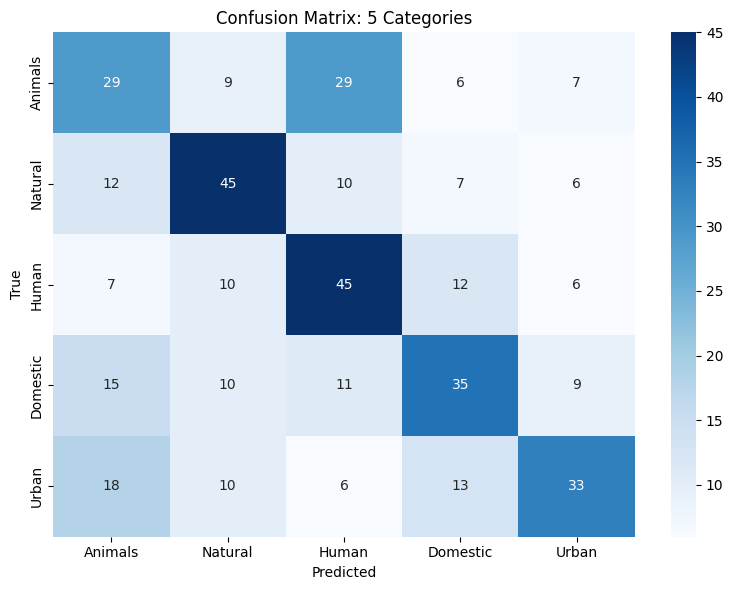

In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn tới file predictions.csv của bạn
predictions_csv = "../../../checkpoints/cnn_cqt_chromagram/predictions.csv"

# ------------------------------------------------------------
# Hàm ánh xạ nhãn -> category
# ------------------------------------------------------------
def get_category(label):
    if 0 <= label <= 9:
        return 0   # Animals
    elif 10 <= label <= 19:
        return 1   # Natural soundscapes & water
    elif 20 <= label <= 29:
        return 2   # Human non-speech
    elif 30 <= label <= 39:
        return 3   # Interior/domestic
    elif 40 <= label <= 49:
        return 4   # Exterior/urban
    else:
        raise ValueError(f"Label {label} out of range 0-49")

def plot_confusion_matrix(cm, labels, title, figsize=(12,10), fmt='d'):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Đọc dữ liệu
# ------------------------------------------------------------
df = pd.read_csv(predictions_csv)
y_true = df['target'].values
y_pred = df['predicted'].values

# ------------------------------------------------------------
# 1. Ma trận nhầm lẫn 50 lớp và classification report
# ------------------------------------------------------------
print("=" * 80)
print("1. FULL 50-CLASS CONFUSION MATRIX & METRICS")
print("=" * 80)

labels_50 = list(range(50))
cm_50 = confusion_matrix(y_true, y_pred, labels=labels_50)

# In báo cáo phân loại chi tiết (precision, recall, f1-score cho từng lớp)
print("\nClassification Report (50 classes):\n")
print(classification_report(y_true, y_pred, labels=labels_50, zero_division=0))

# Vẽ ma trận nhầm lẫn 50x50 (có thể phóng to nếu cần)
plot_confusion_matrix(cm_50, labels_50, title="Confusion Matrix: 50 Classes", figsize=(16,14))

# ------------------------------------------------------------
# 2. Gộp thành 5 categories
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS")
print("=" * 80)

y_true_cat = np.array([get_category(l) for l in y_true])
y_pred_cat = np.array([get_category(l) for l in y_pred])

cat_labels = ["Animals", "Natural", "Human", "Domestic", "Urban"]
cm_cat = confusion_matrix(y_true_cat, y_pred_cat, labels=range(5))

# In báo cáo phân loại cho 5 category
print("\nClassification Report (5 categories):\n")
print(classification_report(y_true_cat, y_pred_cat, labels=range(5),
                            target_names=cat_labels, zero_division=0))

# Vẽ ma trận nhầm lẫn 5x5
plot_confusion_matrix(cm_cat, cat_labels, title="Confusion Matrix: 5 Categories", figsize=(8,6))

1. FULL 50-CLASS CONFUSION MATRIX & METRICS

Classification Report (50 classes):

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.23      0.88      0.37         8
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00         8
           4       0.00      0.00      0.00         8
           5       0.00      0.00      0.00         8
           6       0.00      0.00      0.00         8
           7       0.00      0.00      0.00         8
           8       0.08      0.88      0.15         8
           9       0.00      0.00      0.00         8
          10       0.00      0.00      0.00         8
          11       0.00      0.00      0.00         8
          12       0.07      0.50      0.12         8
          13       0.00      0.00      0.00         8
          14       0.50      0.12      0.20         8
          15       0.00      0.00      0.00         8

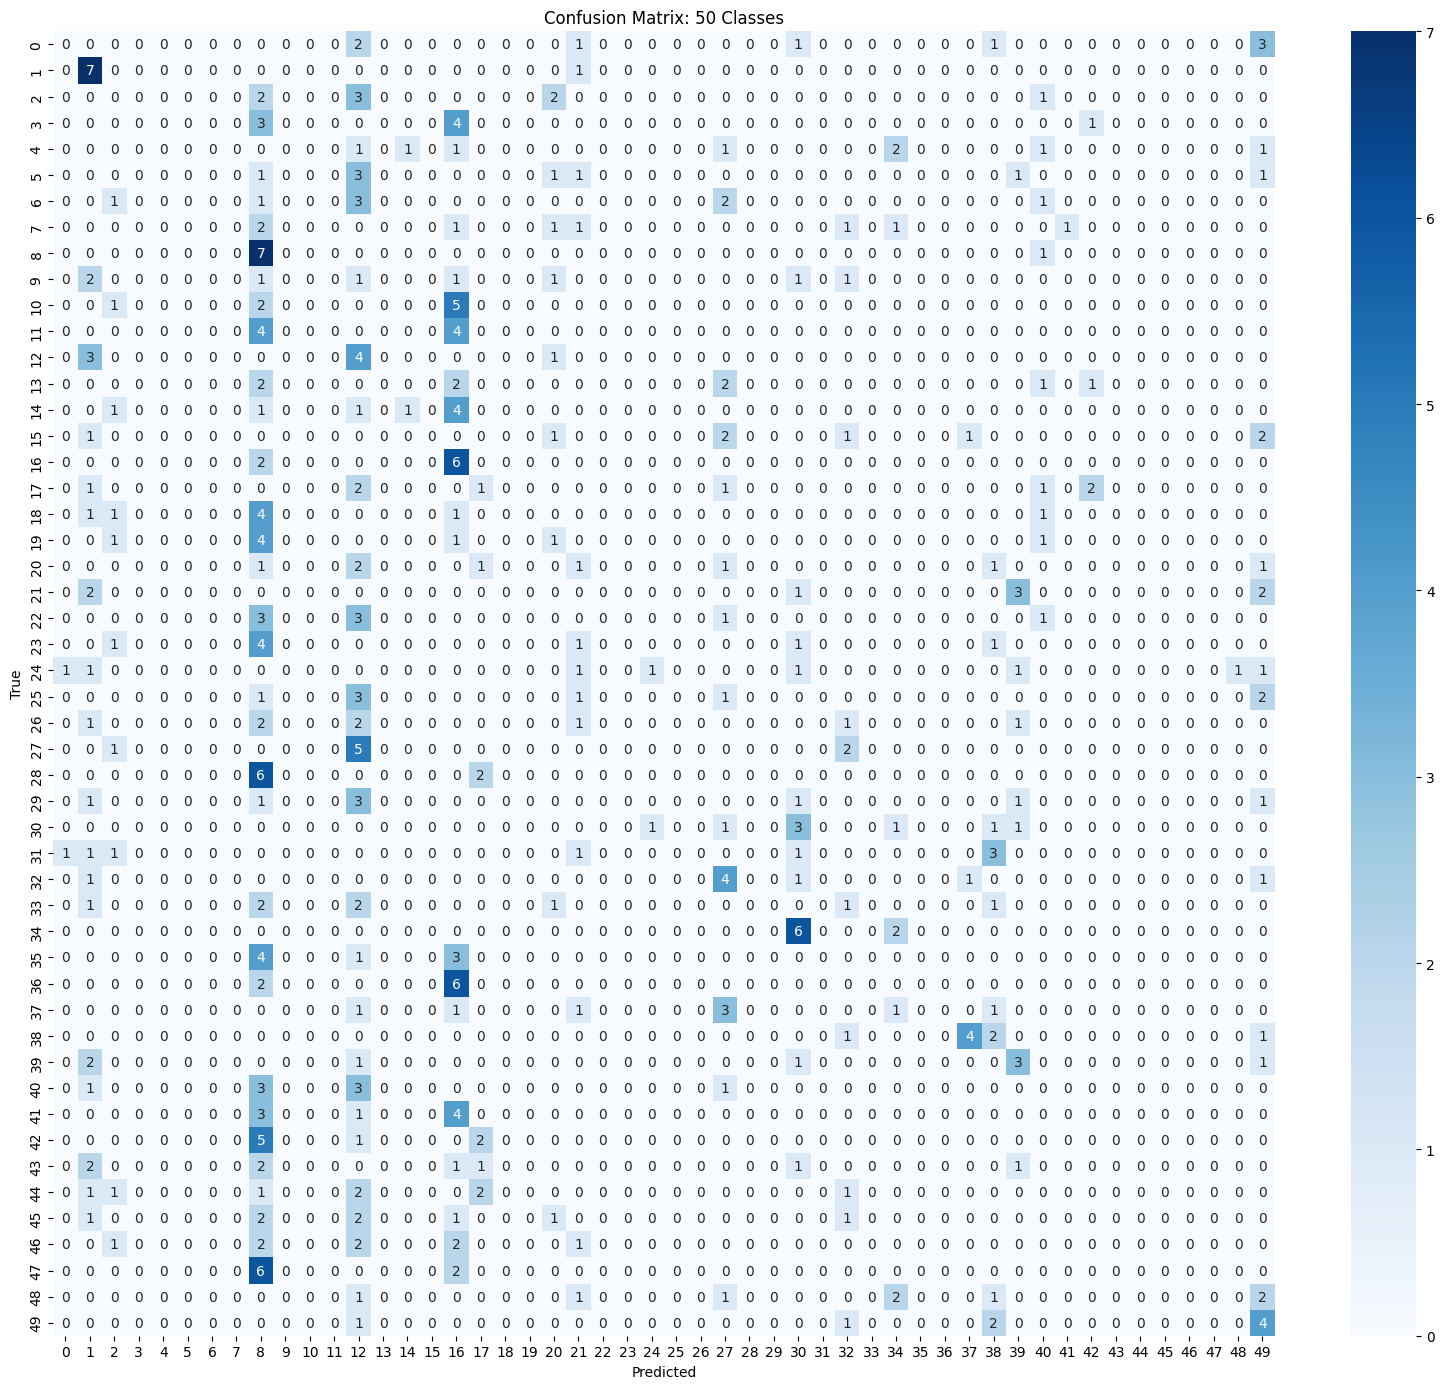


2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS

Classification Report (5 categories):

              precision    recall  f1-score   support

     Animals       0.21      0.34      0.26        80
     Natural       0.27      0.40      0.32        80
       Human       0.20      0.11      0.14        80
    Domestic       0.49      0.44      0.46        80
       Urban       0.16      0.07      0.10        80

    accuracy                           0.27       400
   macro avg       0.27      0.27      0.26       400
weighted avg       0.27      0.27      0.26       400



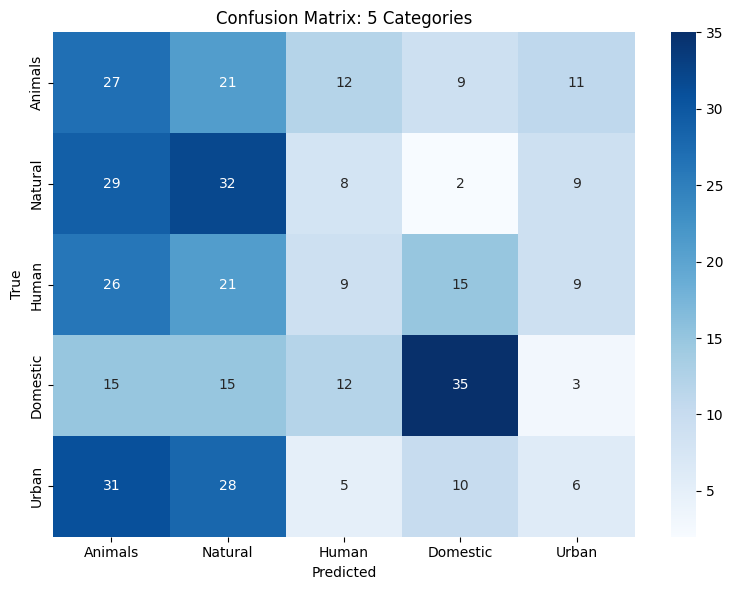

In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn tới file predictions.csv của bạn
predictions_csv = "../../../checkpoints/cnn_cyclic_tempogram/predictions.csv"

# ------------------------------------------------------------
# Hàm ánh xạ nhãn -> category
# ------------------------------------------------------------
def get_category(label):
    if 0 <= label <= 9:
        return 0   # Animals
    elif 10 <= label <= 19:
        return 1   # Natural soundscapes & water
    elif 20 <= label <= 29:
        return 2   # Human non-speech
    elif 30 <= label <= 39:
        return 3   # Interior/domestic
    elif 40 <= label <= 49:
        return 4   # Exterior/urban
    else:
        raise ValueError(f"Label {label} out of range 0-49")

def plot_confusion_matrix(cm, labels, title, figsize=(12,10), fmt='d'):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Đọc dữ liệu
# ------------------------------------------------------------
df = pd.read_csv(predictions_csv)
y_true = df['target'].values
y_pred = df['predicted'].values

# ------------------------------------------------------------
# 1. Ma trận nhầm lẫn 50 lớp và classification report
# ------------------------------------------------------------
print("=" * 80)
print("1. FULL 50-CLASS CONFUSION MATRIX & METRICS")
print("=" * 80)

labels_50 = list(range(50))
cm_50 = confusion_matrix(y_true, y_pred, labels=labels_50)

# In báo cáo phân loại chi tiết (precision, recall, f1-score cho từng lớp)
print("\nClassification Report (50 classes):\n")
print(classification_report(y_true, y_pred, labels=labels_50, zero_division=0))

# Vẽ ma trận nhầm lẫn 50x50 (có thể phóng to nếu cần)
plot_confusion_matrix(cm_50, labels_50, title="Confusion Matrix: 50 Classes", figsize=(16,14))

# ------------------------------------------------------------
# 2. Gộp thành 5 categories
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS")
print("=" * 80)

y_true_cat = np.array([get_category(l) for l in y_true])
y_pred_cat = np.array([get_category(l) for l in y_pred])

cat_labels = ["Animals", "Natural", "Human", "Domestic", "Urban"]
cm_cat = confusion_matrix(y_true_cat, y_pred_cat, labels=range(5))

# In báo cáo phân loại cho 5 category
print("\nClassification Report (5 categories):\n")
print(classification_report(y_true_cat, y_pred_cat, labels=range(5),
                            target_names=cat_labels, zero_division=0))

# Vẽ ma trận nhầm lẫn 5x5
plot_confusion_matrix(cm_cat, cat_labels, title="Confusion Matrix: 5 Categories", figsize=(8,6))

1. FULL 50-CLASS CONFUSION MATRIX & METRICS

Classification Report (50 classes):

              precision    recall  f1-score   support

           0       0.56      0.62      0.59         8
           1       0.41      0.88      0.56         8
           2       0.40      0.50      0.44         8
           3       0.55      0.75      0.63         8
           4       0.30      0.88      0.45         8
           5       0.20      0.12      0.15         8
           6       0.00      0.00      0.00         8
           7       0.00      0.00      0.00         8
           8       0.00      0.00      0.00         8
           9       0.14      0.12      0.13         8
          10       1.00      0.88      0.93         8
          11       0.60      0.75      0.67         8
          12       0.62      1.00      0.76         8
          13       0.29      0.25      0.27         8
          14       0.36      0.50      0.42         8
          15       0.60      0.38      0.46         8

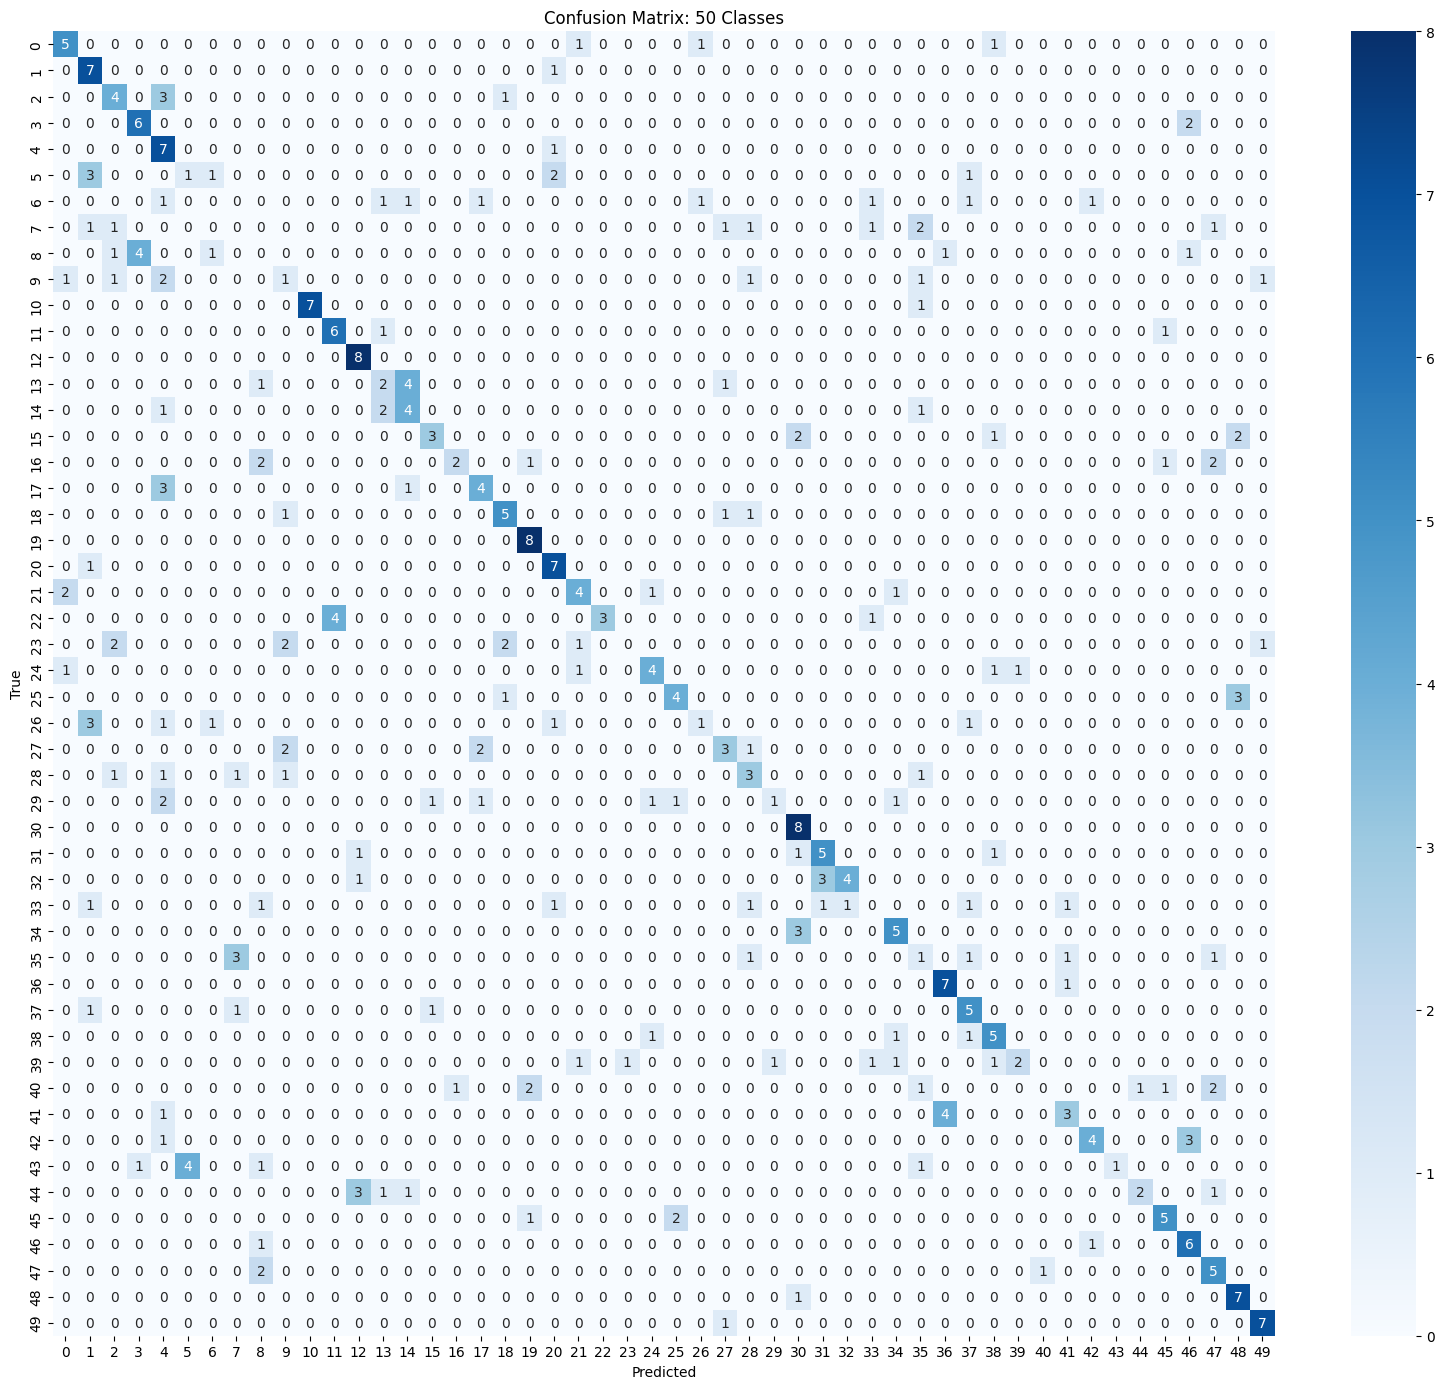


2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS

Classification Report (5 categories):

              precision    recall  f1-score   support

     Animals       0.52      0.64      0.57        80
     Natural       0.68      0.72      0.70        80
       Human       0.62      0.46      0.53        80
    Domestic       0.68      0.74      0.71        80
       Urban       0.71      0.62      0.67        80

    accuracy                           0.64       400
   macro avg       0.64      0.64      0.64       400
weighted avg       0.64      0.64      0.64       400



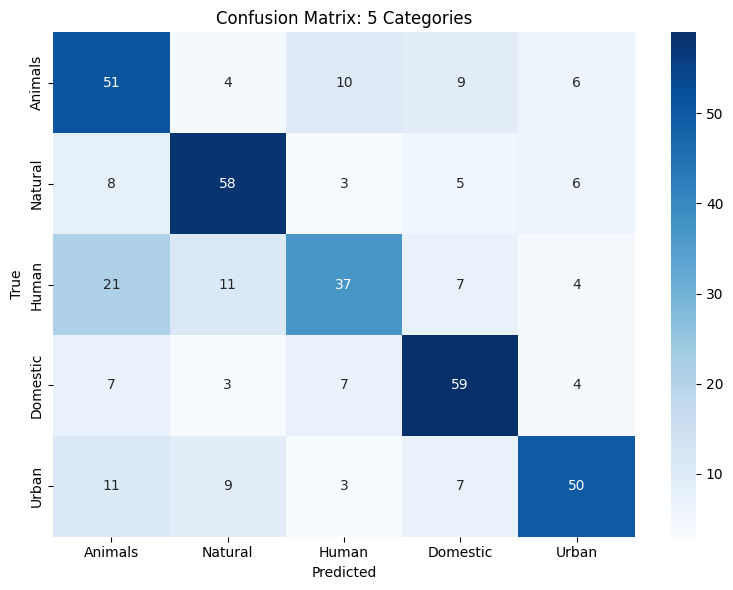

In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn tới file predictions.csv của bạn
predictions_csv = "../../../checkpoints/cnn_melspectrogram/predictions.csv"

# ------------------------------------------------------------
# Hàm ánh xạ nhãn -> category
# ------------------------------------------------------------
def get_category(label):
    if 0 <= label <= 9:
        return 0   # Animals
    elif 10 <= label <= 19:
        return 1   # Natural soundscapes & water
    elif 20 <= label <= 29:
        return 2   # Human non-speech
    elif 30 <= label <= 39:
        return 3   # Interior/domestic
    elif 40 <= label <= 49:
        return 4   # Exterior/urban
    else:
        raise ValueError(f"Label {label} out of range 0-49")

def plot_confusion_matrix(cm, labels, title, figsize=(12,10), fmt='d'):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Đọc dữ liệu
# ------------------------------------------------------------
df = pd.read_csv(predictions_csv)
y_true = df['target'].values
y_pred = df['predicted'].values

# ------------------------------------------------------------
# 1. Ma trận nhầm lẫn 50 lớp và classification report
# ------------------------------------------------------------
print("=" * 80)
print("1. FULL 50-CLASS CONFUSION MATRIX & METRICS")
print("=" * 80)

labels_50 = list(range(50))
cm_50 = confusion_matrix(y_true, y_pred, labels=labels_50)

# In báo cáo phân loại chi tiết (precision, recall, f1-score cho từng lớp)
print("\nClassification Report (50 classes):\n")
print(classification_report(y_true, y_pred, labels=labels_50, zero_division=0))

# Vẽ ma trận nhầm lẫn 50x50 (có thể phóng to nếu cần)
plot_confusion_matrix(cm_50, labels_50, title="Confusion Matrix: 50 Classes", figsize=(16,14))

# ------------------------------------------------------------
# 2. Gộp thành 5 categories
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS")
print("=" * 80)

y_true_cat = np.array([get_category(l) for l in y_true])
y_pred_cat = np.array([get_category(l) for l in y_pred])

cat_labels = ["Animals", "Natural", "Human", "Domestic", "Urban"]
cm_cat = confusion_matrix(y_true_cat, y_pred_cat, labels=range(5))

# In báo cáo phân loại cho 5 category
print("\nClassification Report (5 categories):\n")
print(classification_report(y_true_cat, y_pred_cat, labels=range(5),
                            target_names=cat_labels, zero_division=0))

# Vẽ ma trận nhầm lẫn 5x5
plot_confusion_matrix(cm_cat, cat_labels, title="Confusion Matrix: 5 Categories", figsize=(8,6))

1. FULL 50-CLASS CONFUSION MATRIX & METRICS

Classification Report (50 classes):

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         8
           1       0.57      1.00      0.73         8
           2       0.23      0.38      0.29         8
           3       0.36      0.50      0.42         8
           4       0.50      0.50      0.50         8
           5       0.60      0.38      0.46         8
           6       0.67      0.25      0.36         8
           7       0.29      0.50      0.36         8
           8       0.29      0.25      0.27         8
           9       0.64      0.88      0.74         8
          10       0.86      0.75      0.80         8
          11       0.40      0.75      0.52         8
          12       0.86      0.75      0.80         8
          13       0.43      0.38      0.40         8
          14       0.50      0.50      0.50         8
          15       0.33      0.12      0.18         8

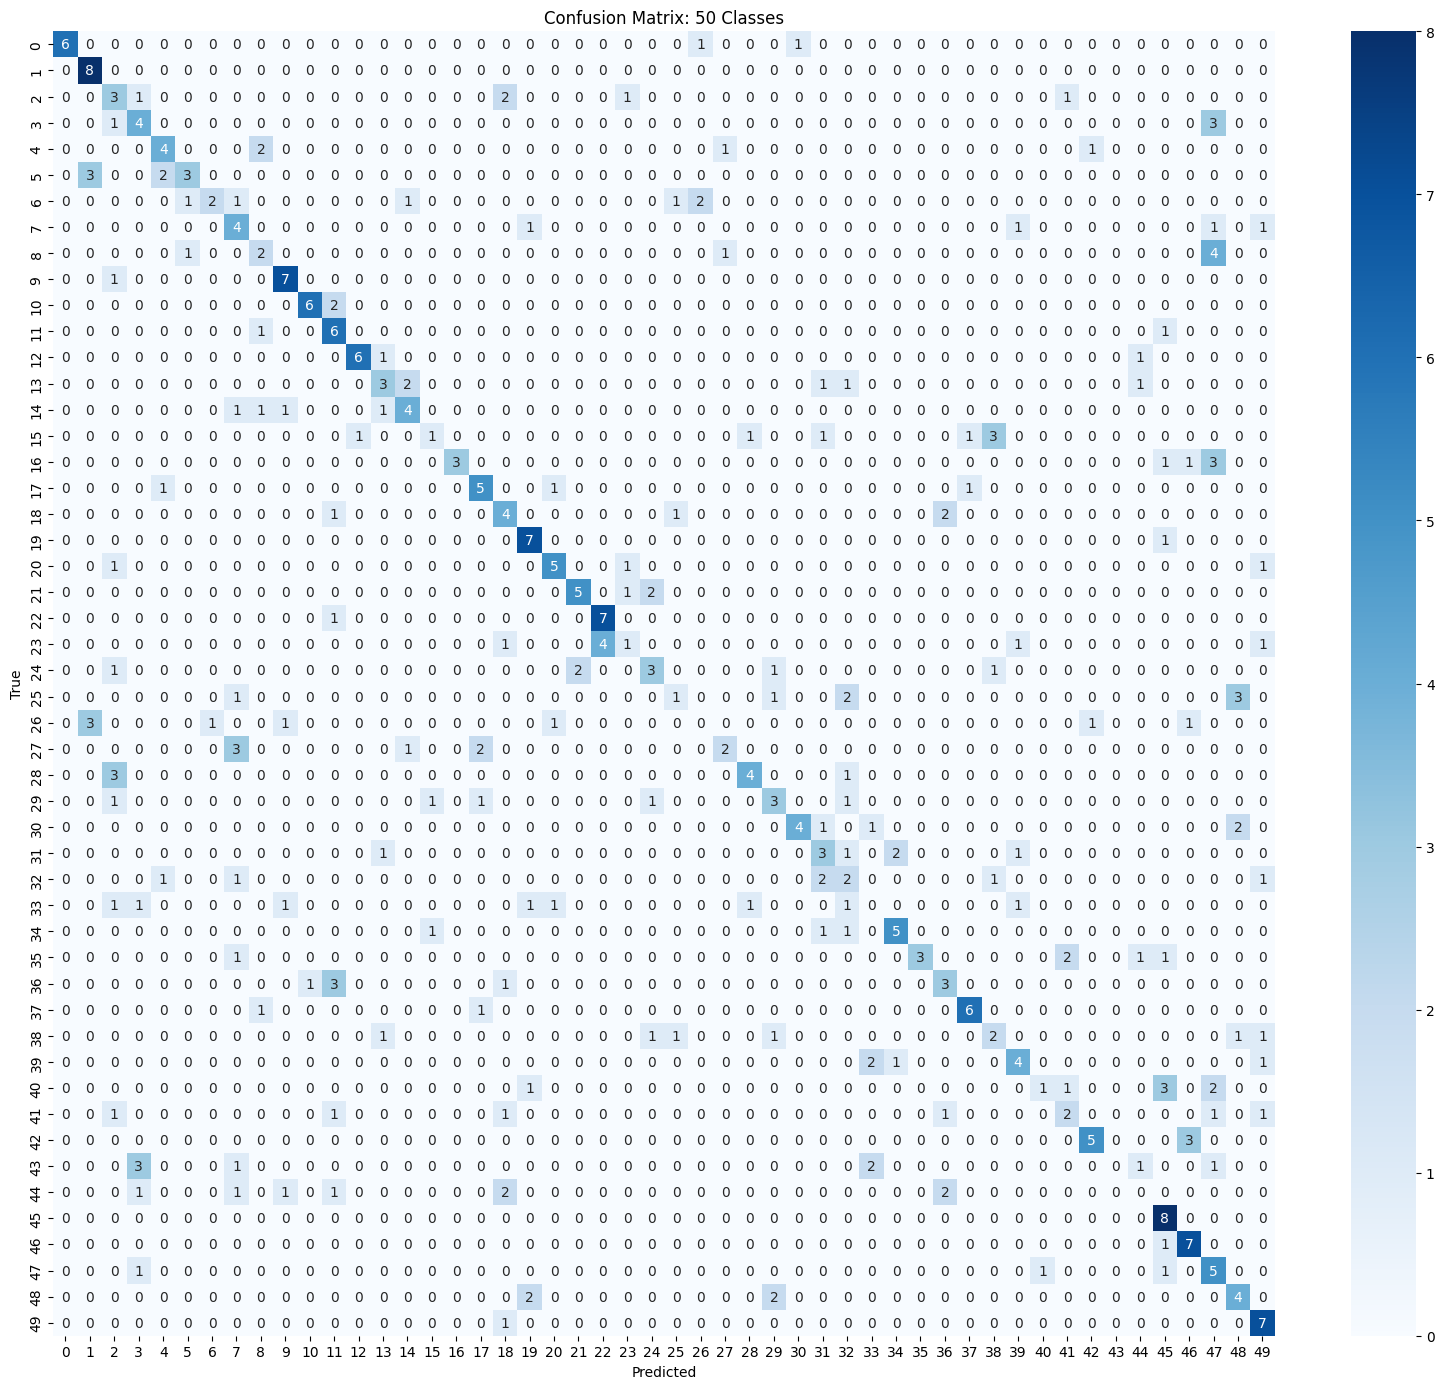


2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS

Classification Report (5 categories):

              precision    recall  f1-score   support

     Animals       0.61      0.70      0.65        80
     Natural       0.64      0.66      0.65        80
       Human       0.73      0.56      0.63        80
    Domestic       0.68      0.60      0.64        80
       Urban       0.60      0.69      0.64        80

    accuracy                           0.64       400
   macro avg       0.65      0.64      0.64       400
weighted avg       0.65      0.64      0.64       400



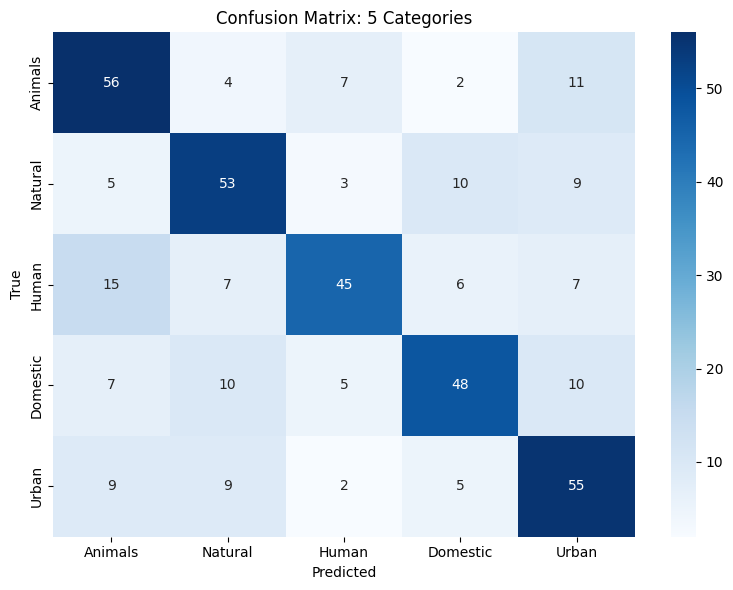

In [17]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn tới file predictions.csv của bạn
predictions_csv = "../../../checkpoints/cnn_mfcc/predictions.csv"

# ------------------------------------------------------------
# Hàm ánh xạ nhãn -> category
# ------------------------------------------------------------
def get_category(label):
    if 0 <= label <= 9:
        return 0   # Animals
    elif 10 <= label <= 19:
        return 1   # Natural soundscapes & water
    elif 20 <= label <= 29:
        return 2   # Human non-speech
    elif 30 <= label <= 39:
        return 3   # Interior/domestic
    elif 40 <= label <= 49:
        return 4   # Exterior/urban
    else:
        raise ValueError(f"Label {label} out of range 0-49")

def plot_confusion_matrix(cm, labels, title, figsize=(12,10), fmt='d'):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Đọc dữ liệu
# ------------------------------------------------------------
df = pd.read_csv(predictions_csv)
y_true = df['target'].values
y_pred = df['predicted'].values

# ------------------------------------------------------------
# 1. Ma trận nhầm lẫn 50 lớp và classification report
# ------------------------------------------------------------
print("=" * 80)
print("1. FULL 50-CLASS CONFUSION MATRIX & METRICS")
print("=" * 80)

labels_50 = list(range(50))
cm_50 = confusion_matrix(y_true, y_pred, labels=labels_50)

# In báo cáo phân loại chi tiết (precision, recall, f1-score cho từng lớp)
print("\nClassification Report (50 classes):\n")
print(classification_report(y_true, y_pred, labels=labels_50, zero_division=0))

# Vẽ ma trận nhầm lẫn 50x50 (có thể phóng to nếu cần)
plot_confusion_matrix(cm_50, labels_50, title="Confusion Matrix: 50 Classes", figsize=(16,14))

# ------------------------------------------------------------
# 2. Gộp thành 5 categories
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("2. CATEGORY-LEVEL (5 GROUPS) CONFUSION MATRIX & METRICS")
print("=" * 80)

y_true_cat = np.array([get_category(l) for l in y_true])
y_pred_cat = np.array([get_category(l) for l in y_pred])

cat_labels = ["Animals", "Natural", "Human", "Domestic", "Urban"]
cm_cat = confusion_matrix(y_true_cat, y_pred_cat, labels=range(5))

# In báo cáo phân loại cho 5 category
print("\nClassification Report (5 categories):\n")
print(classification_report(y_true_cat, y_pred_cat, labels=range(5),
                            target_names=cat_labels, zero_division=0))

# Vẽ ma trận nhầm lẫn 5x5
plot_confusion_matrix(cm_cat, cat_labels, title="Confusion Matrix: 5 Categories", figsize=(8,6))